# Практическая 16 (Саттаров Булат Рамилевич ЭФМО-01-25)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde, norm
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
SEED = 42
np.random.seed(SEED)

## Теоретическая часть

Наивный байесовский классификатор основан на формуле Байеса:

$$P(y_k|x) = \frac{P(y_k)P(x|y_k)}{P(x)}.$$

Для классификации знаменатель $P(x)$ можно не учитывать, потому что он одинаков для всех классов. Тогда выбирается класс с максимальным значением:

$$a(x) = \arg\max_k P(y_k) \prod_i P(x_i|y_k).$$

Главное предположение наивного Байеса — условная независимость признаков внутри класса. В практической части плотности $P(x_i|y_k)$ будут восстановлены по данным.

## Загрузка датасета Iris

In [3]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['class'] = df['target'].map(lambda i: target_names[i])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
print('Размер данных:', df.shape)
print(df['class'].value_counts())
df.describe()

Размер данных: (150, 6)
class
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


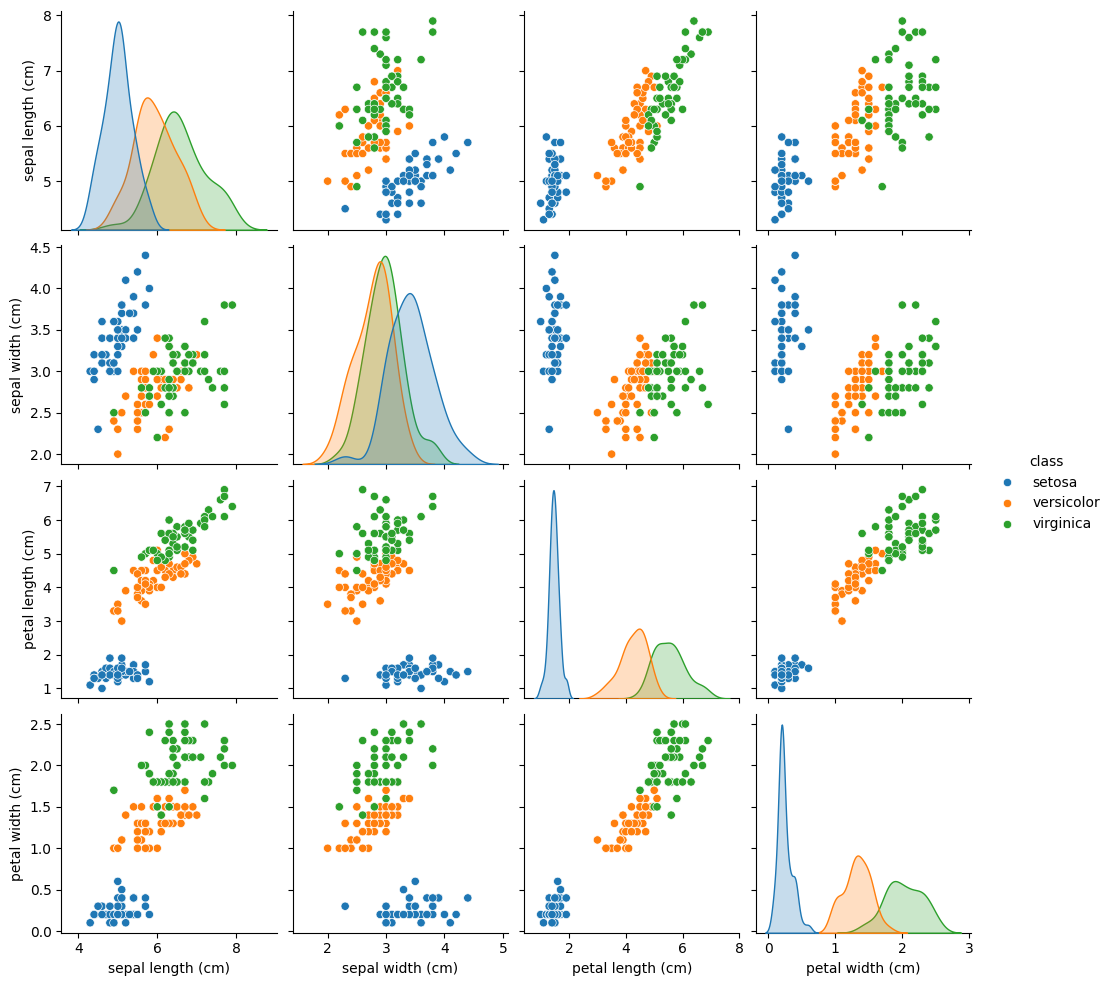

In [5]:
sns.pairplot(df, hue='class', vars=feature_names, palette='tab10')
plt.show()

## Восстановление плотности по данным

Сначала восстановим одномерные плотности признаков для каждого класса с помощью ядерной оценки плотности `gaussian_kde`. Это показывает, как распределены признаки внутри каждого класса.

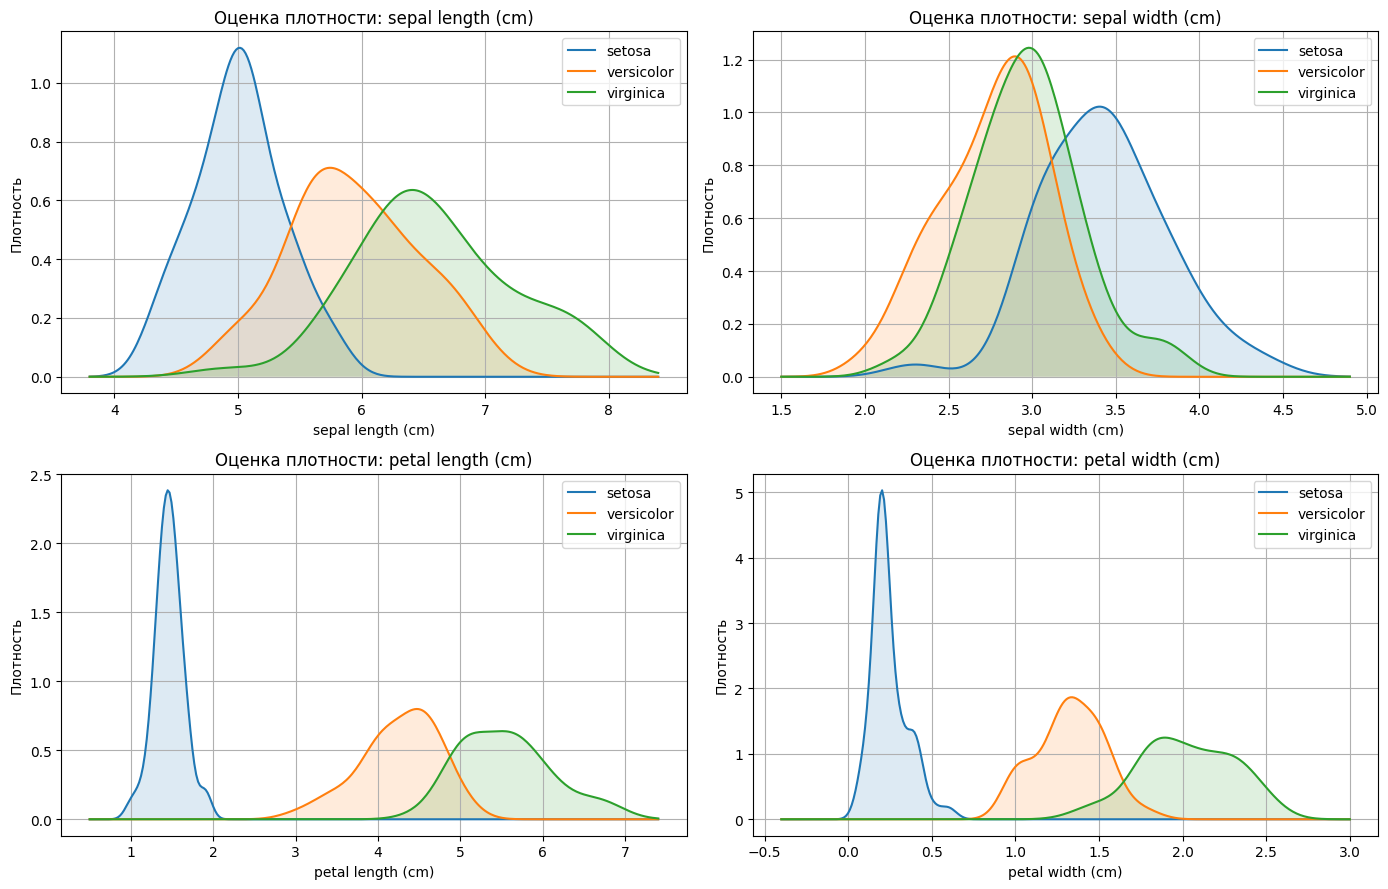

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, feature in zip(axes, feature_names):
    xs = np.linspace(df[feature].min() - 0.5, df[feature].max() + 0.5, 300)
    for class_id, class_name in enumerate(target_names):
        values = df.loc[df['target'] == class_id, feature].values
        kde = gaussian_kde(values)
        ax.plot(xs, kde(xs), label=class_name)
        ax.fill_between(xs, kde(xs), alpha=0.15)
    ax.set_title(f'Оценка плотности: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Плотность')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Собственная реализация наивного байесовского классификатора

Реализуем простой вариант наивного Байеса. Для каждого признака и каждого класса оценим нормальное распределение: среднее и стандартное отклонение. Затем для объекта посчитаем логарифм апостериорной вероятности класса.

In [7]:
class SimpleGaussianNaiveBayes:
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_ = {}
        self.stds_ = {}

        for cls in self.classes_:
            X_cls = X[y == cls]
            self.priors_[cls] = len(X_cls) / len(X)
            self.means_[cls] = X_cls.mean(axis=0)
            self.stds_[cls] = X_cls.std(axis=0) + 1e-9
        return self

    def predict_log_proba(self, X):
        rows = []
        for x in X:
            class_scores = []
            for cls in self.classes_:
                log_prior = np.log(self.priors_[cls])
                log_likelihood = norm.logpdf(x, loc=self.means_[cls], scale=self.stds_[cls]).sum()
                class_scores.append(log_prior + log_likelihood)
            rows.append(class_scores)
        return np.array(rows)

    def predict(self, X):
        scores = self.predict_log_proba(X)
        return self.classes_[np.argmax(scores, axis=1)]

## Обучение и оценка качества

Разделим данные на обучающую и тестовую выборки. Масштабирование для GaussianNB не обязательно, но для собственной реализации оно тоже не требуется, потому что распределение оценивается отдельно по каждому признаку.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

custom_nb = SimpleGaussianNaiveBayes()
custom_nb.fit(X_train, y_train)
custom_pred = custom_nb.predict(X_test)

sklearn_nb = GaussianNB()
sklearn_nb.fit(X_train, y_train)
sklearn_pred = sklearn_nb.predict(X_test)

print('Собственная реализация Naive Bayes')
print('Accuracy:', round(accuracy_score(y_test, custom_pred), 4))
print(classification_report(y_test, custom_pred, target_names=target_names))

print('GaussianNB из sklearn')
print('Accuracy:', round(accuracy_score(y_test, sklearn_pred), 4))
print(classification_report(y_test, sklearn_pred, target_names=target_names))

Собственная реализация Naive Bayes
Accuracy: 0.9111
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

GaussianNB из sklearn
Accuracy: 0.9111
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



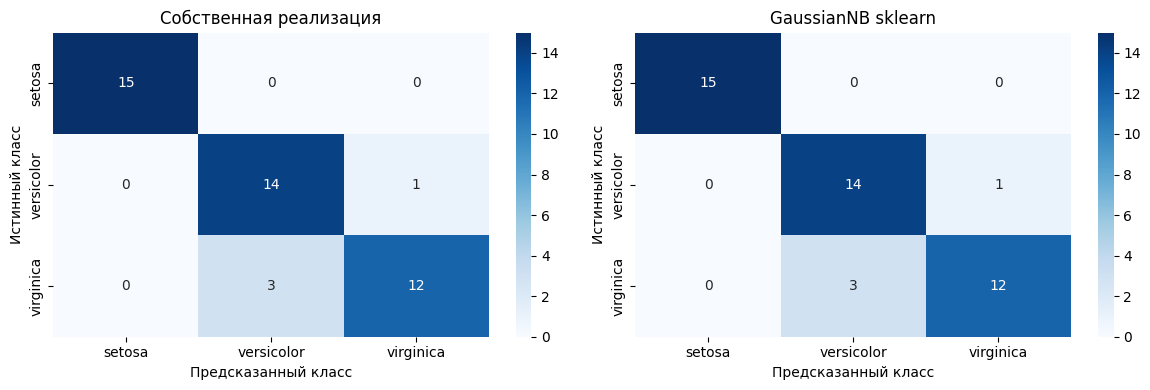

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, title in [
    (axes[0], custom_pred, 'Собственная реализация'),
    (axes[1], sklearn_pred, 'GaussianNB sklearn')
]:
    matrix = confusion_matrix(y_test, pred)
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## Графическое разделение ирисов на классы

Для визуализации построим границы решений по двум признакам: `petal length` и `petal width`. Эти признаки хорошо разделяют три класса ирисов.

In [10]:
selected_features = ['petal length (cm)', 'petal width (cm)']
X_2d = df[selected_features].values
y_2d = y

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d,
    test_size=0.3,
    random_state=SEED,
    stratify=y_2d
)

nb_2d = SimpleGaussianNaiveBayes().fit(X_train_2d, y_train_2d)
pred_2d = nb_2d.predict(X_test_2d)

print('Accuracy по двум признакам:', round(accuracy_score(y_test_2d, pred_2d), 4))

Accuracy по двум признакам: 0.9333


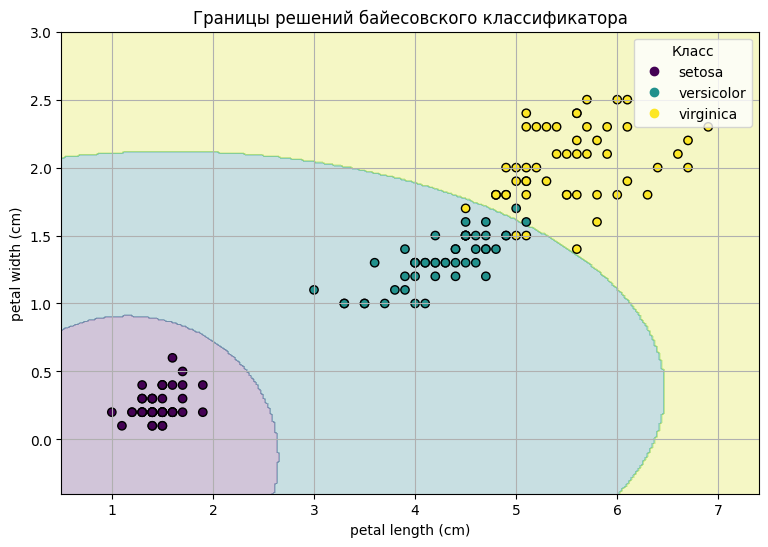

In [11]:
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = nb_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, zz, alpha=0.25, cmap='viridis')
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='viridis', edgecolor='k')
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.title('Границы решений байесовского классификатора')
plt.grid(True)
handles, _ = scatter.legend_elements()
plt.legend(handles, target_names, title='Класс')
plt.show()

## Восстановление двумерной плотности

Дополнительно восстановим двумерную плотность по двум выбранным признакам для каждого класса. Чем выше плотность в области, тем больше вероятность встретить объект данного класса.

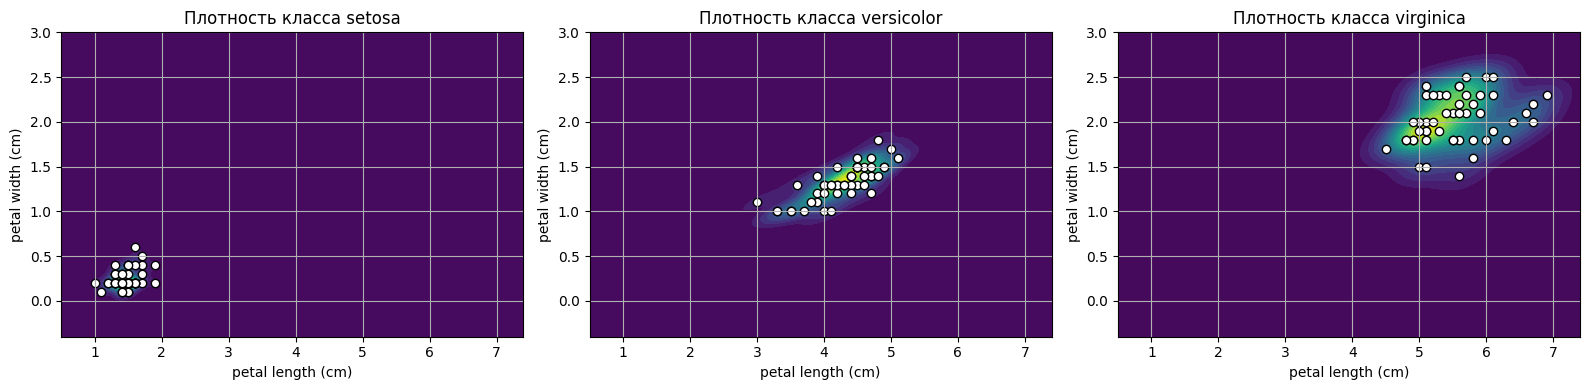

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for class_id, ax in enumerate(axes):
    data_cls = X_2d[y_2d == class_id].T
    kde = gaussian_kde(data_cls)
    positions = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(positions).reshape(xx.shape)

    ax.contourf(xx, yy, density, levels=20, cmap='viridis')
    ax.scatter(X_2d[y_2d == class_id, 0], X_2d[y_2d == class_id, 1], c='white', edgecolor='black')
    ax.set_title(f'Плотность класса {target_names[class_id]}')
    ax.set_xlabel(selected_features[0])
    ax.set_ylabel(selected_features[1])
    ax.grid(True)

plt.tight_layout()
plt.show()

## Сравнение с другими классификаторами

Для контроля сравним байесовский классификатор с деревом решений и случайным лесом на том же датасете.

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'Custom Gaussian NB': custom_nb,
    'GaussianNB sklearn': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(max_depth=3, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'SVM RBF': Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', C=1, gamma='scale'))])
}

rows = []
for name, model in models.items():
    if name == 'Custom Gaussian NB':
        pred = model.predict(X_test)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    rows.append({
        'Метод': name,
        'Accuracy': accuracy_score(y_test, pred)
    })

comparison = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
comparison

,Метод,Accuracy
2,DecisionTree,0.977778
4,SVM RBF,0.933333
0,Custom Gaussian NB,0.911111
1,GaussianNB sklearn,0.911111
3,RandomForest,0.888889


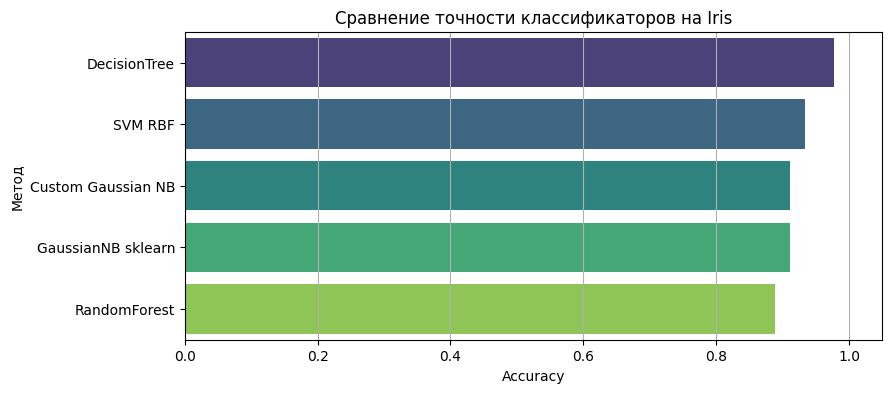

In [14]:
plt.figure(figsize=(9, 4))
sns.barplot(data=comparison, x='Accuracy', y='Метод', palette='viridis')
plt.xlim(0, 1.05)
plt.title('Сравнение точности классификаторов на Iris')
plt.grid(axis='x')
plt.show()

## Вывод

В практической работе был изучен байесовский классификатор и выполнена классификация ирисов Фишера.

Сначала по данным были восстановлены плотности признаков для каждого класса. Затем была реализована собственная версия гауссовского наивного байесовского классификатора. Модель оценивает априорную вероятность каждого класса и правдоподобие признаков при условии класса, после чего выбирает класс с максимальной апостериорной вероятностью.

На тестовой выборке собственная реализация и `GaussianNB` из `sklearn` показали высокую точность. Результат также был представлен графически: построены границы решений и двумерные плотности для классов Iris.